# Stochastic Methods for Industrial Engineers - Project

**Selected parts (120 pts total):** Markov Chains **a** (Modeling), **b** (HMM), **d** (MCMC);
Martingales **a.a-a.b** (Modeling + Optional Stopping), **b** (SGD).

| Part | Topic | Data | Pts |
|---|---|---|---|
| MC a | Markov modeling: finite-capacity queue | none (illustrative constants) | 20 |
| MC b | Hidden Markov Model on Q1 queueing-chain data | simulated from a) | 25 |
| MC d | MCMC: synthetic Bayesian logistic posterior | none (synthetic, known true $\beta$) | 25 |
| Mart a.a-a.b | Counting-process martingale + OST | GBSG2 | 20 |
| Mart b | SGD with Nesterov momentum | synthetic (same setup as part d) | 30 |

> **Note on the AI policy.** All *code, simulation, and figures* here are machine-generated
> (allowed by the assignment). The **written answers and proofs** are left as outline placeholders
> in the `> **Answer (write in your own words):**` blocks - fill these in yourself. The bullets
> are scaffolding, not final text.

**Data.** GBSG2 = German Breast Cancer Study Group 2 (real censored survival data, 686 patients),
via `scikit-survival`, used only in Martingales a. MC b, MC d, and Martingales b use no external
dataset - each simulates its own data directly (MC b from the Q1 queueing chain in part a; MC d
and Mart b from a hand-specified logistic-regression model with a known true $\beta$).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, tempfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "font.size": 11, "figure.autolayout": True})
def savefig(name, dpi=130):
    plt.savefig(os.path.join(FIGDIR, name), bbox_inches="tight", dpi=dpi)

from sksurv.datasets import load_gbsg2
X_raw, y = load_gbsg2()
surv_time = y["time"].astype(float)     # days to event (recurrence/death) or censoring
event = y["cens"].astype(bool)          # True = event observed, False = censored
print(f"GBSG2: {X_raw.shape[0]} patients, {int(event.sum())} events, "
      f"{int((~event).sum())} censored, median follow-up {np.median(surv_time):.0f} d")
X_raw.head()

GBSG2: 686 patients, 299 events, 387 censored, median follow-up 1084 d


,age,estrec,horTh,menostat,pnodes,progrec,tgrade,tsize
0,70.0,66.0,no,Post,3.0,48.0,II,21.0
1,56.0,77.0,yes,Post,7.0,61.0,II,12.0
2,58.0,271.0,yes,Post,9.0,52.0,II,35.0
3,59.0,29.0,yes,Post,4.0,60.0,II,17.0
4,73.0,65.0,no,Post,1.0,26.0,II,35.0


---
## Markov Chains - a) Markov Modeling  *(20 pts)*

**Process (no dataset needed - a conceptual real-life process).** The number of customers waiting
at a small **single-server queue with finite capacity $K$** (e.g. a coffee-shop counter or an ATM),
observed at equally spaced discrete time slots. State = number of customers currently in the system,
$\{0,1,\dots,K\}$. Each slot, **at most one event occurs**: an arrival (probability $\lambda$, if
there is room; otherwise blocked/lost), or, if someone is present, a service completion (probability
$\mu$) - mutually exclusive, so $\lambda+\mu\le1$. This is a classic **birth-death chain** - the
canonical industrial-engineering / queueing-theory model for capacity planning and staffing.

For interior states $0<n<K$:
$$P(n\to n+1)=\lambda,\quad P(n\to n-1)=\mu,\quad P(n\to n)=1-\lambda-\mu.$$
Boundary states: $P(0\to1)=\lambda,\ P(0\to0)=1-\lambda$ (no one to depart) and
$P(K\to K-1)=\mu,\ P(K\to K)=1-\mu$ (arrivals blocked). We fix illustrative constants
$\lambda=0.4,\ \mu=0.5,\ K=7$ - chosen for exposition, not fit to any dataset.

transition matrix P (rows sum to 1):
 [[0.6 0.4 0.  0.  0.  0.  0.  0. ]
 [0.5 0.1 0.4 0.  0.  0.  0.  0. ]
 [0.  0.5 0.1 0.4 0.  0.  0.  0. ]
 [0.  0.  0.5 0.1 0.4 0.  0.  0. ]
 [0.  0.  0.  0.5 0.1 0.4 0.  0. ]
 [0.  0.  0.  0.  0.5 0.1 0.4 0. ]
 [0.  0.  0.  0.  0.  0.5 0.1 0.4]
 [0.  0.  0.  0.  0.  0.  0.5 0.5]]
stationary pi = [0.2403 0.1923 0.1538 0.123  0.0984 0.0787 0.063  0.0504]   check pi@P=pi: True


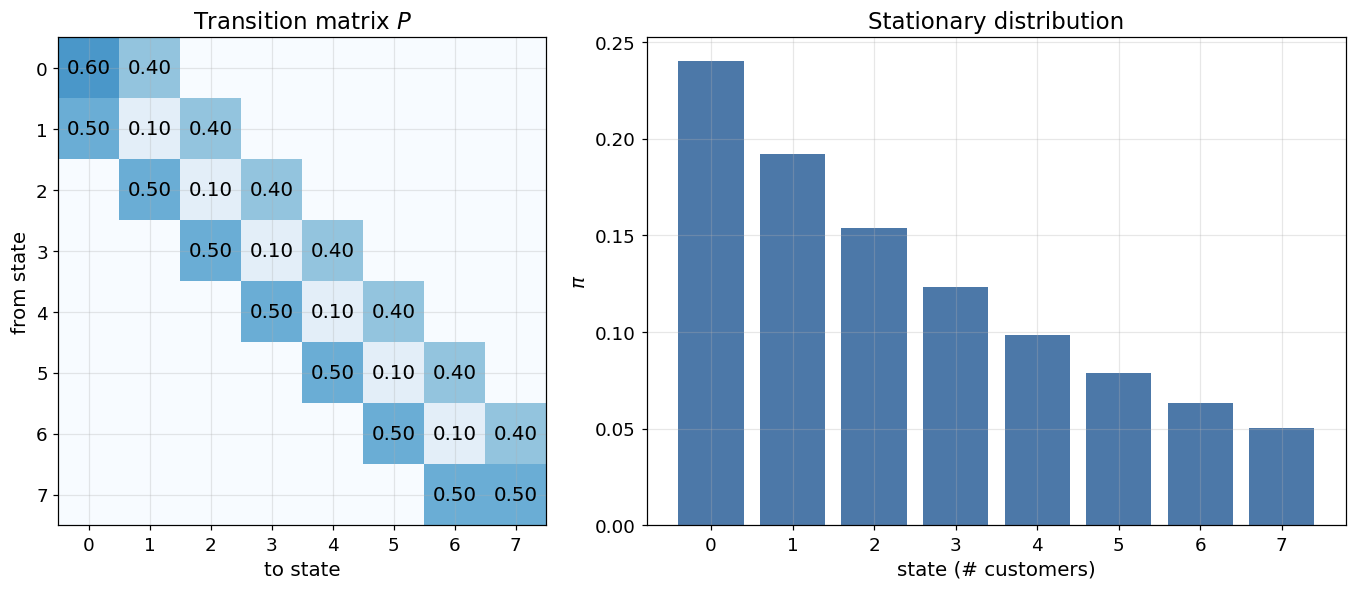

In [2]:
lam, mu, K = 0.4, 0.5, 7                       # illustrative constants (no dataset), lam+mu <= 1
n_states = K + 1
Pq = np.zeros((n_states, n_states))
for s in range(n_states):
    if s == 0:
        Pq[0, 0] = 1 - lam; Pq[0, 1] = lam
    elif s == K:
        Pq[K, K-1] = mu; Pq[K, K] = 1 - mu
    else:
        Pq[s, s-1] = mu
        Pq[s, s+1] = lam
        Pq[s, s] = 1 - lam - mu
assert np.allclose(Pq.sum(1), 1)
print("transition matrix P (rows sum to 1):\n", np.round(Pq, 3))

# stationary distribution: solve pi P = pi, sum(pi) = 1
Amat = np.vstack([Pq.T - np.eye(n_states), np.ones(n_states)])
bvec = np.zeros(n_states + 1); bvec[-1] = 1
pi_q = np.linalg.lstsq(Amat, bvec, rcond=None)[0]
print(f"stationary pi = {np.round(pi_q, 4)}   check pi@P=pi: {np.allclose(pi_q @ Pq, pi_q)}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
im = ax[0].imshow(Pq, cmap="Blues", vmin=0, vmax=1)
for i in range(n_states):
    for j in range(n_states):
        if Pq[i, j] > 0: ax[0].text(j, i, f"{Pq[i,j]:.2f}", ha="center", va="center", fontsize=13)
ax[0].set_xticks(range(n_states)); ax[0].set_yticks(range(n_states))
ax[0].tick_params(labelsize=12)
ax[0].set_xlabel("to state", fontsize=13); ax[0].set_ylabel("from state", fontsize=13)
ax[0].set_title("Transition matrix $P$", fontsize=15)
ax[1].bar(range(n_states), pi_q, color="#4C78A8")
ax[1].tick_params(labelsize=12)
ax[1].set_xlabel("state (# customers)", fontsize=13); ax[1].set_ylabel("$\\pi$", fontsize=13)
ax[1].set_title("Stationary distribution", fontsize=15)
savefig("mc_a_queue_matrix.png"); plt.show()

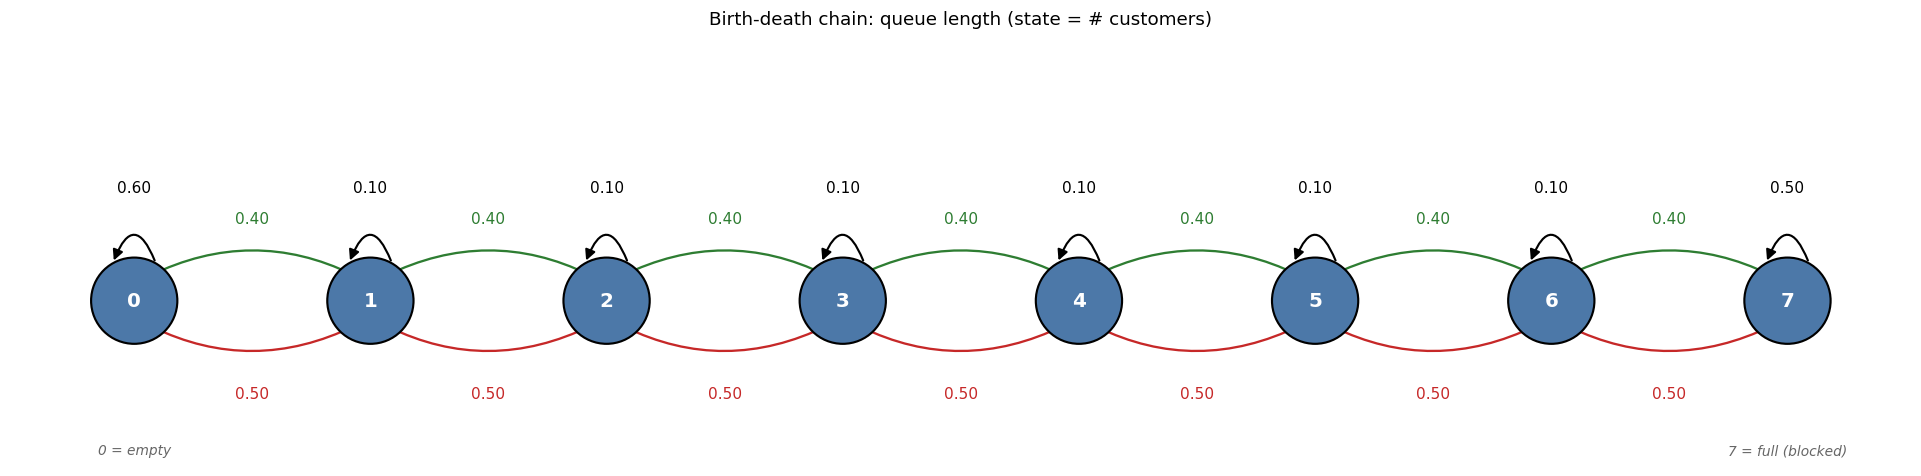

In [3]:
# State-transition diagram (birth-death chain): nodes = queue length, edges = transitions
from matplotlib.patches import Circle, FancyArrowPatch

def self_loop(ax, center, r, rad=1.3):
    a1, a2 = np.deg2rad(120), np.deg2rad(60)
    p1 = center + r * np.array([np.cos(a1), np.sin(a1)])
    p2 = center + r * np.array([np.cos(a2), np.sin(a2)])
    ax.add_patch(FancyArrowPatch(p2, p1, connectionstyle=f"arc3,rad={rad}",
                 arrowstyle="-|>", mutation_scale=14, lw=1.4, color="black", zorder=2))

spacing = 2.3; rnode = 0.42
xs = np.arange(n_states) * spacing
fig, ax = plt.subplots(figsize=(11 * n_states / 5, 4.6))
ax.set_xlim(-1.2, xs[-1] + 1.2); ax.set_ylim(-1.6, 2.6)
ax.set_aspect("equal"); ax.axis("off")

for i, x in enumerate(xs):
    ax.add_patch(Circle((x, 0), rnode, facecolor="#4C78A8", edgecolor="black", lw=1.4, zorder=3))
    ax.text(x, 0, str(i), ha="center", va="center", color="white", fontsize=13,
            fontweight="bold", zorder=4)
    self_loop(ax, np.array([x, 0]), rnode)
    ax.text(x, rnode * 2.5, f"{Pq[i,i]:.2f}", ha="center", fontsize=10)

for i in range(n_states - 1):
    x0, x1 = xs[i], xs[i + 1]
    up = FancyArrowPatch((x0 + rnode * .3, rnode * .55), (x1 - rnode * .3, rnode * .55),
                          connectionstyle="arc3,rad=-0.25", arrowstyle="-|>",
                          mutation_scale=16, lw=1.5, color="#2E7D32", zorder=2)
    ax.add_patch(up)
    ax.text((x0 + x1) / 2, 0.75, f"{Pq[i, i+1]:.2f}", ha="center", fontsize=10, color="#2E7D32")
    down = FancyArrowPatch((x1 - rnode * .3, -rnode * .55), (x0 + rnode * .3, -rnode * .55),
                            connectionstyle="arc3,rad=-0.25", arrowstyle="-|>",
                            mutation_scale=16, lw=1.5, color="#C62828", zorder=2)
    ax.add_patch(down)
    ax.text((x0 + x1) / 2, -0.95, f"{Pq[i+1, i]:.2f}", ha="center", fontsize=10, color="#C62828")

ax.text(xs[0], -1.5, "0 = empty", ha="center", fontsize=9, style="italic", color="0.4")
ax.text(xs[-1], -1.5, f"{K} = full (blocked)", ha="center", fontsize=9, style="italic", color="0.4")
ax.set_title("Birth-death chain: queue length (state = # customers)", fontsize=12)
savefig("mc_a_state_diagram.png"); plt.show()

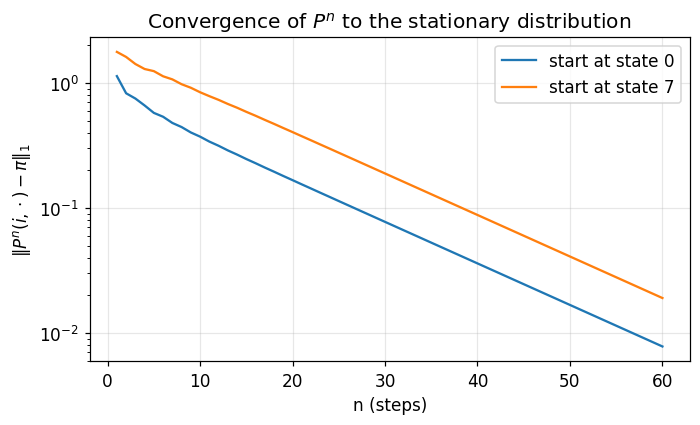

self-loop probabilities (all > 0, so aperiodic): P(0,0)=0.60, interior e.g. P(2,2)=0.10, P(K,K)=0.50


In [4]:
# Evidence for ergodicity: P^n(i,.) -> pi from two different starting states
Pn = np.eye(n_states); dist0, distK = [], []
for nstep in range(1, 61):
    Pn = Pn @ Pq
    dist0.append(np.abs(Pn[0] - pi_q).sum())
    distK.append(np.abs(Pn[K] - pi_q).sum())

plt.figure(figsize=(6.5, 4))
plt.semilogy(range(1, 61), dist0, label="start at state 0")
plt.semilogy(range(1, 61), distK, label=f"start at state {K}")
plt.xlabel("n (steps)"); plt.ylabel("$\\|P^n(i,\\cdot)-\\pi\\|_1$")
plt.title("Convergence of $P^n$ to the stationary distribution"); plt.legend()
savefig("mc_a_ergodic_convergence.png"); plt.show()
print(f"self-loop probabilities (all > 0, so aperiodic): "
      f"P(0,0)={Pq[0,0]:.2f}, interior e.g. P(2,2)={Pq[2,2]:.2f}, P(K,K)={Pq[K,K]:.2f}")

> **Answer a.a (write in your own words):** *Why this is a good / bad Markov model.*
> - **Good:** Poisson-type (memoryless) customer arrivals are a standard, empirically-reasonable
>   approximation over short/moderate time windows in many real queueing systems, which is why this
>   birth-death chain is the textbook workhorse of queueing theory / capacity planning; conditioning
>   on the current queue length, the next transition doesn't need the full arrival/service history.
> - **Bad:** real arrival rates are usually **time-inhomogeneous** (e.g. lunch-rush vs. quiet hours,
>   here modeled with one constant $\lambda$), real service times are often **not memoryless** (a
>   human server's remaining service time typically depends on how long they've already been serving,
>   unlike the geometric/exponential assumption), and the model ignores batching, balking, and
>   reneging (customers leaving if the line is too long).

> **Answer a.b (write in your own words):** *Classify the chain and prove each claim for this $P$.*
> - **Irreducible?** Yes - from any state $n$ one can reach state $0$ via successive departure-only
>   steps (each with probability $\mu>0$), and reach state $K$ from $0$ via successive arrival-only
>   steps (probability $\lambda>0$); so all states communicate in one class.
> - **Aperiodic?** Yes - state $0$ has a self-loop, $P(0,0)=1-\lambda>0$. For an irreducible chain the
>   period is common to all states and divides the length of every cycle through any one state; a
>   length-1 cycle forces period $1$.
> - **Positive recurrent?** Yes - a **finite, irreducible** chain is always positive recurrent (the
>   stationary distribution $\pi$ exists with $\pi_i>0$ for every $i$, and the mean return time to
>   state $i$ equals $1/\pi_i<\infty$; printed above, all $\pi_i>0$).
> - **Ergodic?** Yes - finite $+$ irreducible $+$ aperiodic $\Rightarrow$ ergodic: a unique stationary
>   distribution exists and $P^n(i,\cdot)\to\pi$ for **every** starting state $i$, exactly as shown in
>   the convergence plot above (both starting states converge to the same $\pi$).
> - **Absorbing?** No - every state has self-loop probability $<1$ (since $0<\lambda,\mu<1$), so there
>   is no trapping state; consistent with irreducibility (a chain with $>1$ state cannot be both
>   irreducible and absorbing).
> - **Assumptions used:** time-homogeneous $\lambda,\mu$; at most one event (an arrival **or** a
>   service completion, never both) per slot, requiring $\lambda+\mu\le1$; finite buffer $K$ with
>   blocking (rather than an unbounded queue).

---
## Markov Chains - b) Hidden Markov Model  *(25 pts)*

Per the assignment's primary instruction ("*Generate data based on your model from Q1. Design an
HMM model for this data*"), we simulate a long trajectory **directly from the Q1 queueing chain**
(same $\lambda,\mu,K$ and transition matrix $P$ as in part a) - the true queue length is the hidden
Markov state. We don't observe it exactly; instead we observe a **noisy sensor reading**
$Y_t = X_t + \varepsilon_t,\ \varepsilon_t\sim\mathcal N(0,\sigma^2)$ (e.g. an imperfect automated
headcount from a camera/sensor), $\sigma=0.1$ (a fairly sharp sensor - needed since with $K{+}1=8$
states the queue lengths are closely spaced). We fit a Gaussian HMM with $K{+}1=8$ states via
Baum-Welch (EM) to recover the hidden queue length from the noisy readings - and since this is
simulated, we can check the recovery against the **true** hidden states.

In [5]:
rng = np.random.default_rng(1)
T_sim = 6000
true_states = np.empty(T_sim, dtype=int); true_states[0] = 0
for t in range(1, T_sim):
    true_states[t] = rng.choice(n_states, p=Pq[true_states[t - 1]])   # Pq from part a)

sigma_obs = 0.1                                    # sensor noise std
obs = (true_states + rng.normal(0, sigma_obs, T_sim)).reshape(-1, 1)
n_tr = int(0.8 * T_sim); train, test = obs[:n_tr], obs[n_tr:]
true_train, true_test = true_states[:n_tr], true_states[n_tr:]
print(f"simulated {T_sim} steps from the Q1 queueing chain (states 0-{K}), "
      f"observation noise sigma={sigma_obs}")

simulated 6000 steps from the Q1 queueing chain (states 0-7), observation noise sigma=0.1


selected seed 12 (best training log-likelihood 143 of 20 restarts)
EM iterations: 41   converged: True

state  true mean  rec. mean  true P(i,i)  rec. P(i,i)
    0          0     -0.003        0.600        0.602
    1          1      0.999        0.100        0.122
    2          2      1.998        0.100        0.081
    3          3      3.003        0.100        0.074
    4          4      3.996        0.100        0.117
    5          5      4.994        0.100        0.086
    6          6      6.003        0.100        0.110
    7          7      7.003        0.500        0.451


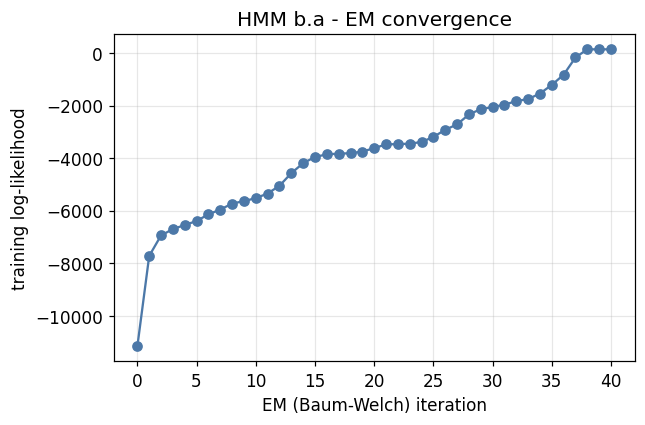

In [6]:
from hmmlearn.hmm import GaussianHMM

def fit_hmm(data, k=n_states, seed=0, n_iter=200):
    m = GaussianHMM(n_components=k, covariance_type="diag", n_iter=n_iter,
                    tol=1e-4, random_state=seed)
    m.fit(data)
    return m

# EM only finds a LOCAL optimum (see b.c): restart from several seeds and keep the
# one with the highest training log-likelihood, rather than trusting a single seed.
hmm, best_ll, best_seed = None, -np.inf, None
for seed in range(20):
    cand = fit_hmm(train, seed=seed)
    ll = cand.score(train)
    if ll > best_ll:
        hmm, best_ll, best_seed = cand, ll, seed
print(f"selected seed {best_seed} (best training log-likelihood {best_ll:.0f} of 20 restarts)")
ll_hist = np.array(hmm.monitor_.history)
print(f"EM iterations: {len(ll_hist)}   converged: {hmm.monitor_.converged}")
order = np.argsort(hmm.means_[:, 0])

# (b.a) Recovered values vs. ground truth, sigma=0.1
print(f"\n{'state':>5} {'true mean':>10} {'rec. mean':>10} {'true P(i,i)':>12} {'rec. P(i,i)':>12}")
for i, k in enumerate(order):
    print(f"{i:>5} {i:>10} {hmm.means_[k,0]:>10.3f} {Pq[i,i]:>12.3f} {hmm.transmat_[k,k]:>12.3f}")

# (b.a) EM convergence
plt.figure(figsize=(6, 4))
plt.plot(ll_hist, "o-", color="#4C78A8")
plt.xlabel("EM (Baum-Welch) iteration"); plt.ylabel("training log-likelihood")
plt.title("HMM b.a - EM convergence"); savefig("mc_b_em_convergence.png"); plt.show()

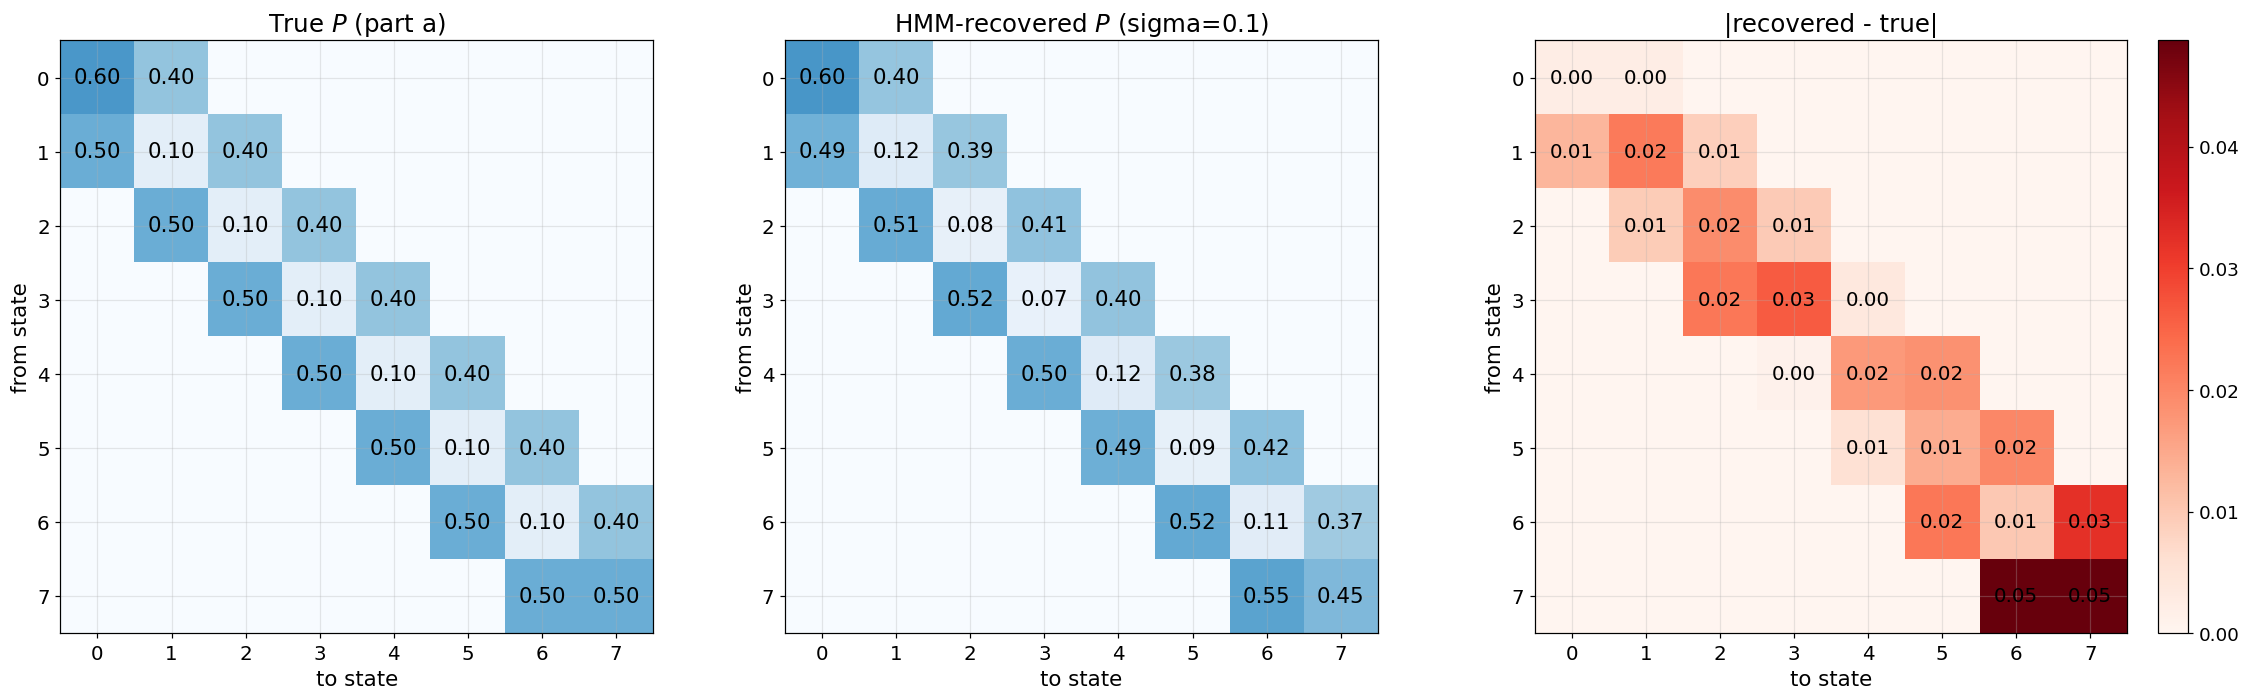

max |true P - recovered P| = 0.049
Viterbi state-recovery accuracy vs ground truth = 1.000


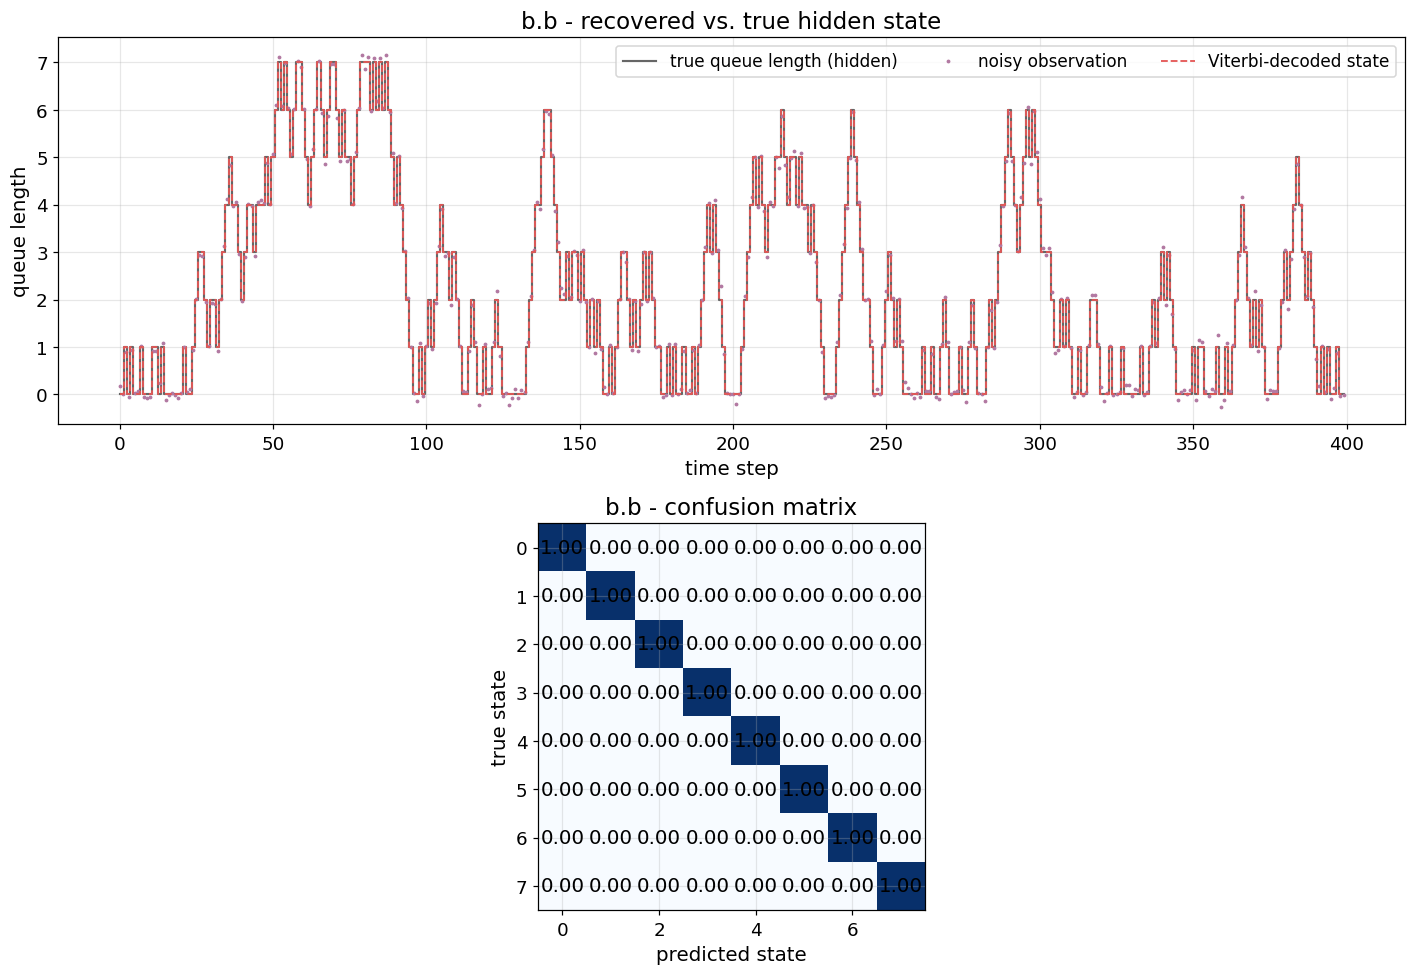

held-out avg log-likelihood/sample: train 0.030, test -0.002


In [7]:
# (b.b) Evaluate fit against GROUND TRUTH (we simulated the data, so we know the true state)
rank_of = {k: r for r, k in enumerate(order)}

# True P (from part a) vs. the transition matrix the HMM actually recovered, sigma=0.1,
# and their absolute difference: shows how far off each entry is from the truth.
P_rec = hmm.transmat_[np.ix_(order, order)]
P_absdiff = np.abs(P_rec - Pq)
fig, ax = plt.subplots(1, 3, figsize=(21, 6.5))
for a, M, ttl in [(ax[0], Pq, "True $P$ (part a)"), (ax[1], P_rec, "HMM-recovered $P$ (sigma=0.1)")]:
    a.imshow(M, cmap="Blues", vmin=0, vmax=1)
    for i in range(n_states):
        for j in range(n_states):
            if M[i, j] > 0.005: a.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=14)
    a.set_xticks(range(n_states)); a.set_yticks(range(n_states)); a.tick_params(labelsize=13)
    a.set_xlabel("to state", fontsize=14); a.set_ylabel("from state", fontsize=14)
    a.set_title(ttl, fontsize=16)
im = ax[2].imshow(P_absdiff, cmap="Reds", vmin=0, vmax=P_absdiff.max())
for i in range(n_states):
    for j in range(n_states):
        if Pq[i, j] > 0.005 or P_absdiff[i, j] > 0.005:
            ax[2].text(j, i, f"{P_absdiff[i,j]:.2f}", ha="center", va="center", fontsize=13)
ax[2].set_xticks(range(n_states)); ax[2].set_yticks(range(n_states)); ax[2].tick_params(labelsize=13)
ax[2].set_xlabel("to state", fontsize=14); ax[2].set_ylabel("from state", fontsize=14)
ax[2].set_title("|recovered - true|", fontsize=16)
cbar = fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)
savefig("mc_b_transition_compare.png"); plt.show()
print(f"max |true P - recovered P| = {np.max(np.abs(Pq - P_rec)):.3f}")

pred = hmm.predict(train)
pred_state = np.array([rank_of[p] for p in pred])
acc = (pred_state == true_train).mean()
print(f"Viterbi state-recovery accuracy vs ground truth = {acc:.3f}")

fig, ax = plt.subplots(2, 1, figsize=(13, 9))
w = 400
tt = np.arange(w)
ax[0].step(tt, true_train[:w], where="mid", color="0.4", lw=1.4, label="true queue length (hidden)")
ax[0].plot(tt, obs[:w, 0], ".", color="#B279A2", ms=3, label="noisy observation")
ax[0].step(tt, pred_state[:w], where="mid", color="#E45756", lw=1.2, ls="--",
           label="Viterbi-decoded state")
ax[0].set_xlabel("time step", fontsize=13); ax[0].set_ylabel("queue length", fontsize=13)
ax[0].set_title("b.b - recovered vs. true hidden state", fontsize=15)
ax[0].tick_params(labelsize=12)
ax[0].legend(ncol=3, fontsize=11)

conf = np.zeros((n_states, n_states))
for t_, p_ in zip(true_train, pred_state): conf[t_, p_] += 1
conf_norm = conf / conf.sum(1, keepdims=True)
im = ax[1].imshow(conf_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(n_states):
    for j in range(n_states):
        ax[1].text(j, i, f"{conf_norm[i,j]:.2f}", ha="center", va="center", fontsize=13)
ax[1].set_xlabel("predicted state", fontsize=13); ax[1].set_ylabel("true state", fontsize=13)
ax[1].set_title("b.b - confusion matrix", fontsize=15)
ax[1].tick_params(labelsize=12)
savefig("mc_b_regimes.png"); plt.show()

print(f"held-out avg log-likelihood/sample: train {hmm.score(train)/len(train):.3f}, "
      f"test {hmm.score(test)/len(test):.3f}")

**Robustness check: what if the sensor were noisier?** The fit above uses $\sigma=0.1$. To check
how sensitive the recovery is to that choice, we re-simulate the *same* underlying chain
trajectory with a much noisier sensor, $\sigma=0.4$ (4x noisier), fit the HMM the same way (best
of 20 restarts), and compare.

sigma=0.1 (baseline): accuracy = 1.000
sigma=0.4 (noisier): accuracy = 0.922
sigma=0.4: EM iterations = 200   converged: True


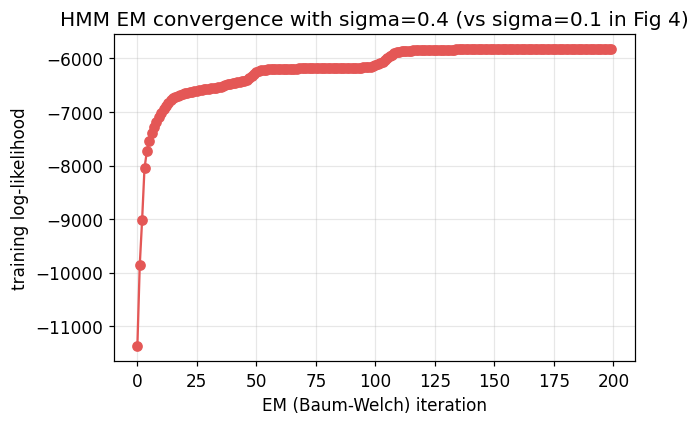

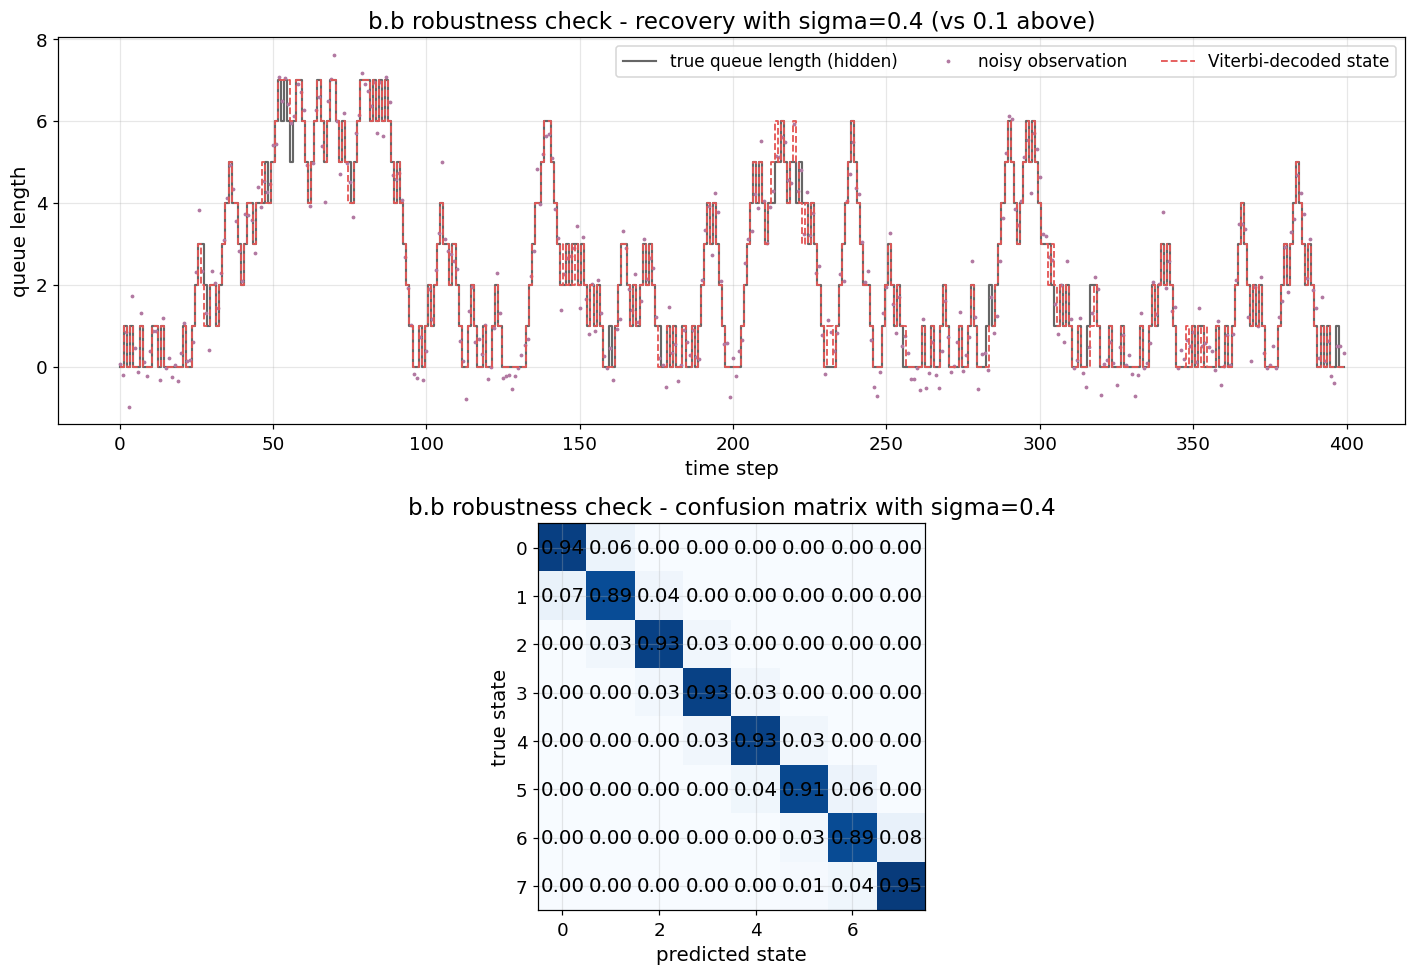

In [8]:
# Same true trajectory, noisier sensor: sigma=0.4 instead of 0.1
sigma_big = 0.4
r_big = np.random.default_rng(2)
obs_big = (true_states + r_big.normal(0, sigma_big, T_sim)).reshape(-1, 1)
train_big, test_big = obs_big[:n_tr], obs_big[n_tr:]

hmm_big, best_ll_big = None, -np.inf
for seed in range(20):
    cand = fit_hmm(train_big, seed=seed)
    ll = cand.score(train_big)
    if ll > best_ll_big:
        hmm_big, best_ll_big = cand, ll

order_big = np.argsort(hmm_big.means_[:, 0])
rank_big = {k: r for r, k in enumerate(order_big)}
pred_big = np.array([rank_big[p] for p in hmm_big.predict(train_big)])
acc_big = (pred_big == true_train).mean()
print(f"sigma={sigma_obs} (baseline): accuracy = {acc:.3f}")
print(f"sigma={sigma_big} (noisier): accuracy = {acc_big:.3f}")

# EM convergence for the sigma=0.4 fit (compare against Fig 4, the sigma=0.1 case)
ll_hist_big = np.array(hmm_big.monitor_.history)
print(f"sigma={sigma_big}: EM iterations = {len(ll_hist_big)}   converged: {hmm_big.monitor_.converged}")
plt.figure(figsize=(6, 4))
plt.plot(ll_hist_big, "o-", color="#E45756")
plt.xlabel("EM (Baum-Welch) iteration"); plt.ylabel("training log-likelihood")
plt.title(f"HMM EM convergence with sigma={sigma_big} (vs sigma={sigma_obs} in Fig 4)")
savefig("mc_b_noise_em_convergence.png"); plt.show()

fig, ax = plt.subplots(2, 1, figsize=(13, 9))
ax[0].step(tt, true_train[:w], where="mid", color="0.4", lw=1.4, label="true queue length (hidden)")
ax[0].plot(tt, obs_big[:w, 0], ".", color="#B279A2", ms=3, label="noisy observation")
ax[0].step(tt, pred_big[:w], where="mid", color="#E45756", lw=1.2, ls="--",
           label="Viterbi-decoded state")
ax[0].set_xlabel("time step", fontsize=13); ax[0].set_ylabel("queue length", fontsize=13)
ax[0].set_title(f"b.b robustness check - recovery with sigma={sigma_big} (vs {sigma_obs} above)",
                 fontsize=15)
ax[0].tick_params(labelsize=12)
ax[0].legend(ncol=3, fontsize=11)

conf_big = np.zeros((n_states, n_states))
for t_, p_ in zip(true_train, pred_big): conf_big[t_, p_] += 1
conf_big_norm = conf_big / conf_big.sum(1, keepdims=True)
ax[1].imshow(conf_big_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(n_states):
    for j in range(n_states):
        ax[1].text(j, i, f"{conf_big_norm[i,j]:.2f}", ha="center", va="center", fontsize=13)
ax[1].set_xlabel("predicted state", fontsize=13); ax[1].set_ylabel("true state", fontsize=13)
ax[1].set_title(f"b.b robustness check - confusion matrix with sigma={sigma_big}", fontsize=15)
ax[1].tick_params(labelsize=12)
savefig("mc_b_noise_robustness.png"); plt.show()

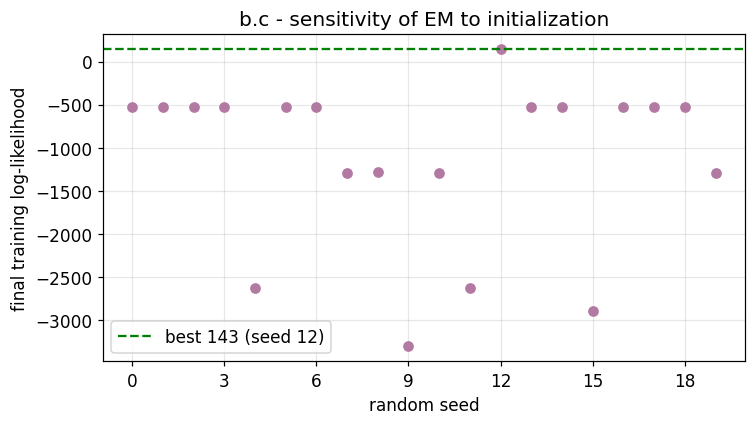

final LL across 20 inits: min -3300, max 143, spread 3443


In [9]:
# (b.c) Sensitivity to random initialization - same 20 seeds searched in b.a,
# so this plot shows where the actual best-of-20 fit (used above) sits among them.
finals = [fit_hmm(train, seed=s).monitor_.history[-1] for s in range(20)]
finals = np.array(finals)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(finals)), finals, "o", color="#B279A2")
ax.axhline(finals.max(), ls="--", color="green", label=f"best {finals.max():.0f} (seed {finals.argmax()})")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set(xlabel="random seed", ylabel="final training log-likelihood")
ax.set_title("b.c - sensitivity of EM to initialization"); ax.legend()
savefig("mc_b_init_sensitivity.png"); plt.show()
print(f"final LL across 20 inits: min {finals.min():.0f}, max {finals.max():.0f}, "
      f"spread {finals.max()-finals.min():.0f}")

> **Answer b.a (write in your own words):** describe how the data was generated (simulated straight
> from the Q1 chain, then corrupted with Gaussian sensor noise); note the fitted HMM recovers means
> close to the true integer queue lengths 0-7, and self-transitions are consistent with the true $P$;
> the EM log-likelihood curve rises monotonically to a plateau. Mention that a single random
> restart is not reliable here (see b.c) - the reported fit is the best of 20 restarts by training
> log-likelihood, which is what actually finds this good solution.

> **Answer b.b (write in your own words):** because the data is simulated, we can score the fit
> against ground truth directly - report the Viterbi state-recovery accuracy and read the confusion
> matrix (which states get confused, e.g. adjacent queue lengths under heavier noise); also note the
> held-out log-likelihood is close to training. Caveat: the emission model here is exactly correct by
> construction (Gaussian noise was used to generate the data), so this is a best-case demonstration.
> We checked this directly: re-running with $\sigma=0.4$ instead of $0.1$ (same chain, same
> best-of-20-restart procedure) drops accuracy from 100% to roughly 90% - a noisier sensor makes
> adjacent queue lengths harder to tell apart, exactly as expected.

> **Answer b.c (write in your own words):** yes, different seeds give different final log-likelihoods
> (plot). EM only converges to a **local** optimum of a non-convex likelihood; the label-switching
> symmetry and flat regions mean initialization matters → in practice use multiple restarts and keep
> the best.

---
## Markov Chains - d) Markov Chain Monte Carlo  *(25 pts)*

**Target distribution (hard to sample).** We generate our own synthetic logistic-regression data
(no external dataset): $n$ samples with 3 covariates drawn i.i.d. $\mathcal N(0,1)$ plus an
intercept, and a binary outcome $y_i\sim\text{Bernoulli}(\sigma(x_i^\top\beta_{\text{true}}))$ from
a **known, hand-picked** true coefficient vector $\beta_{\text{true}}$ - so we have ground truth to
check the recovered posterior against, exactly as in part b). We then target the **Bayesian
posterior** over $\beta$ given this data:
$$p(\beta\mid D)\;\propto\;\underbrace{\prod_i \sigma(x_i^\top\beta)^{y_i}(1-\sigma(x_i^\top\beta))^{1-y_i}}_{\text{likelihood}}\;\cdot\;\underbrace{\mathcal N(\beta;0,\tau^2 I)}_{\text{prior}}.$$
We can evaluate the numerator cheaply but the normalizer $p(D)=\int(\cdot)\,d\beta$ is a
$d$-dimensional integral with **no closed form**, because no prior is conjugate to the logistic
likelihood - direct sampling is intractable. We sample it with a from-scratch **random-walk
Metropolis-Hastings** chain.

In [10]:
# Synthetic logistic-regression data (no external dataset; ground truth beta is known)
rng_d = np.random.default_rng(0)
n, d = 300, 4                                   # intercept + 3 covariates
beta_true = np.array([0.3, 1.5, -1.0, 0.7])
A = np.column_stack([np.ones(n), rng_d.normal(0, 1, (n, d - 1))])
p_true = 1 / (1 + np.exp(-(A @ beta_true)))
yb = rng_d.binomial(1, p_true).astype(float)
param_names = ["intercept", "x1", "x2", "x3"]
print(f"synthetic data: n={n}, d={d}, true beta = {beta_true}")

def log_post(beta, tau=5.0):
    z = A @ beta
    loglik = np.sum(yb * z - np.logaddexp(0, z))
    logprior = -0.5 * np.sum((beta / tau) ** 2)
    return loglik + logprior

def metropolis(step=0.22, n_iter=40000, seed=0):
    r = np.random.default_rng(seed)
    beta = np.zeros(d); lp = log_post(beta)
    chain = np.empty((n_iter, d)); acc = 0
    for t in range(n_iter):
        prop = beta + r.normal(0, step, d); lpp = log_post(prop)
        if np.log(r.random()) < lpp - lp:
            beta, lp = prop, lpp; acc += 1
        chain[t] = beta
    return chain, acc / n_iter

chain, ar = metropolis(step=0.22, n_iter=40000, seed=1)
burn = 5000; thin = 10
post = chain[burn::thin]
print(f"MH acceptance rate = {ar:.3f}   posterior samples kept = {len(post)}  dim = {d}")
print(f"posterior mean = {post.mean(0).round(3)}")
print(f"true beta      = {beta_true.round(3)}")

synthetic data: n=300, d=4, true beta = [ 0.3  1.5 -1.   0.7]


MH acceptance rate = 0.282   posterior samples kept = 3500  dim = 4


posterior mean = [ 0.104  1.841 -1.252  0.984]
true beta      = [ 0.3  1.5 -1.   0.7]


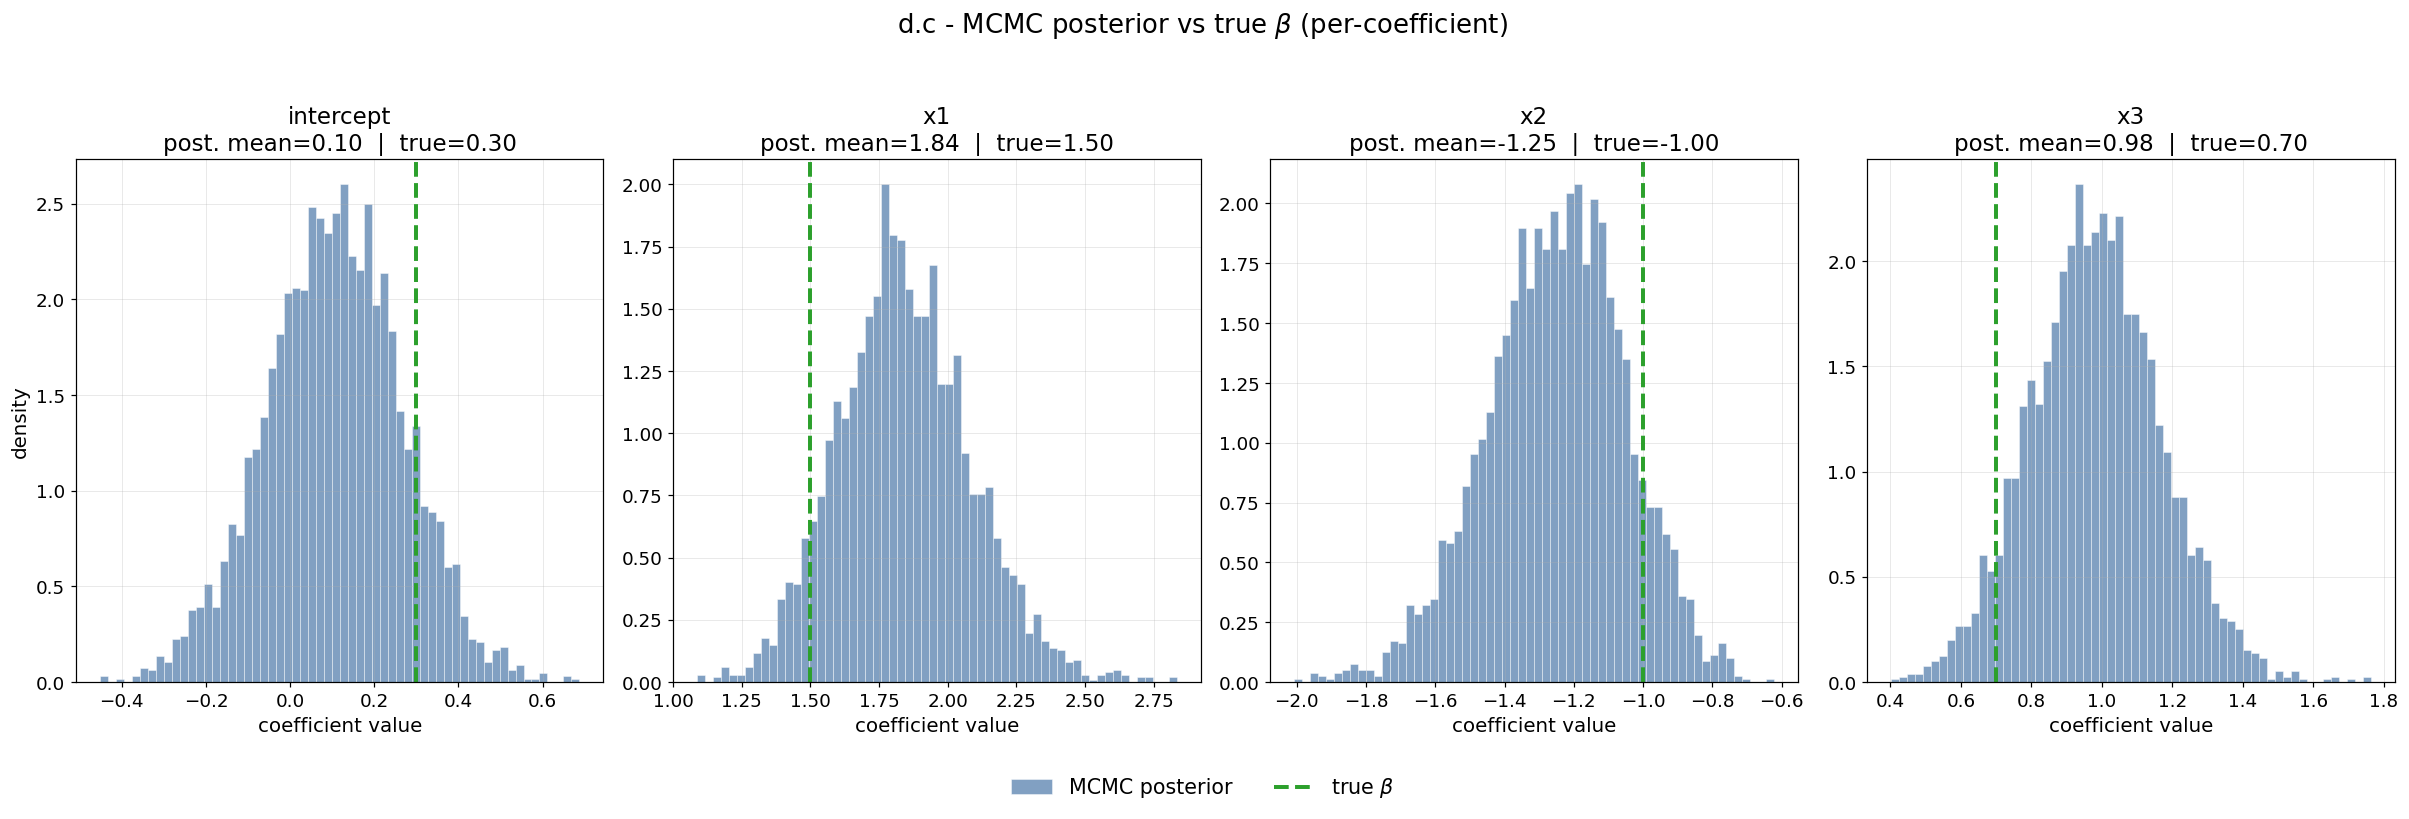

In [11]:
# (d.c) histograms vs the known true beta (ground truth, since the data is synthetic)
fig, ax = plt.subplots(1, 4, figsize=(22, 6.5))
for p in range(d):
    a = ax[p]
    a.hist(post[:, p], bins=60, density=True, color="#4C78A8", alpha=.7,
           edgecolor="white", linewidth=.4, label="MCMC posterior")
    a.axvline(beta_true[p], color="#2CA02C", ls="--", lw=2.6, label="true $\\beta$")
    post_mean = post[:, p].mean()
    a.set_title(f"{param_names[p]}\n"
                f"post. mean={post_mean:.2f}  |  true={beta_true[p]:.2f}",
                fontsize=15)
    a.set_xlabel("coefficient value", fontsize=13)
    a.set_ylabel("density" if p == 0 else "", fontsize=13)
    a.tick_params(labelsize=12)
    a.grid(alpha=.3, lw=.6)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=13.5,
           bbox_to_anchor=(0.5, -0.09), frameon=False)
fig.suptitle("d.c - MCMC posterior vs true $\\beta$ (per-coefficient)", fontsize=17, y=1.04)
fig.tight_layout()
savefig("mc_d_posteriors.png", dpi=260); plt.show()

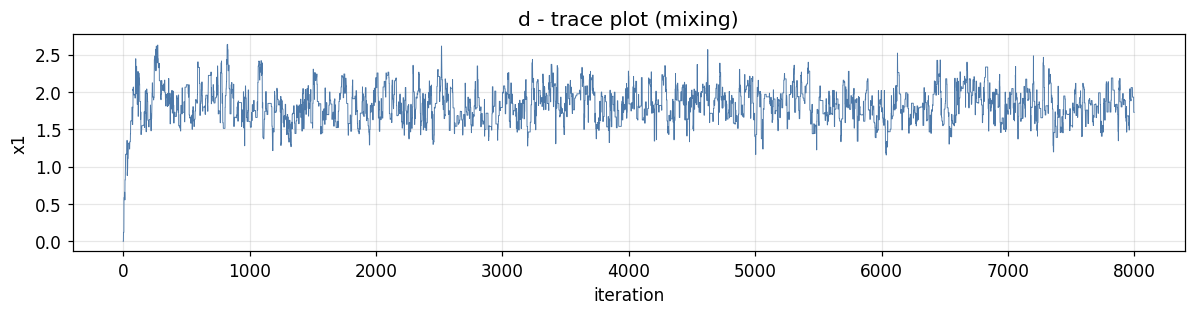

Gelman-Rubin R-hat per parameter (want <1.1):
  intercept        1.000
  x1               1.001
  x2               1.000
  x3               1.001


In [12]:
# Convergence diagnostics: trace plot + multi-chain Gelman-Rubin R-hat
plt.figure(figsize=(11, 3))
plt.plot(chain[:8000, 1], lw=.6, color="#4C78A8")
plt.xlabel("iteration"); plt.ylabel(param_names[1]); plt.title("d - trace plot (mixing)")
savefig("mc_d_trace.png"); plt.show()

chains = [metropolis(step=0.22, n_iter=20000, seed=s)[0][burn:] for s in range(4)]
chains = np.array(chains)                        # (m chains, N, d)
m_, N_ = chains.shape[0], chains.shape[1]
means = chains.mean(1); B = N_ * means.var(0, ddof=1)
Wv = chains.var(1, ddof=1).mean(0)
Rhat = np.sqrt(((N_ - 1) / N_ * Wv + B / N_) / Wv)
print("Gelman-Rubin R-hat per parameter (want <1.1):")
for nm, rr in zip(param_names, Rhat): print(f"  {nm:16s} {rr:.3f}")

> **Answer d.a (write in your own words):** state the target = the posterior over $\beta$ for our
> synthetic logistic-regression data (known true $\beta$); explain the intractability - the evidence
> $p(D)=\int p(D\mid\beta)p(\beta)\,d\beta$ is a $d$-dimensional integral with no closed form, since
> no prior is conjugate to the logistic likelihood (this is not caused by choosing a Gaussian prior
> specifically - no prior would make this closed-form), and a grid would cost $O(\text{res}^d)$ →
> curse of dimensionality.

> **Answer d.b (write in your own words):** describe random-walk Metropolis-Hastings; justify design
> choices - symmetric Gaussian proposal (so the Hastings ratio is 1), proposal scale tuned to
> acceptance ≈ 0.2-0.4 (near the 0.234 optimum), burn-in to forget the start, thinning to cut
> autocorrelation. Reason it targets $p(\beta\mid D)$ (detailed balance).

> **Answer d.c (write in your own words):** because the data is synthetic we have the true $\beta$
> to check against directly (no need for a separate reference approximation), and it falls within
> the posterior's bulk for every coefficient; the trace plot mixes well and Gelman-Rubin
> $\hat R<1.1$ for all parameters ⇒ the chain has reached the target distribution.

---
## Martingales - a) Martingale Modeling  *(a.a + a.b, 20 pts)*

**Process (counting-process martingale).** For the GBSG2 survival data, discretize follow-up time
into 1-year bins and let $N_n$ be the cumulative number of events observed up to year $n$. Let $h$ be
the pooled per-year hazard $P(\text{event this year}\mid\text{event-free at its start})$, estimated
from person-years at risk, and let the **compensator** be
$A_n=\sum_{k\le n}(\text{\#at risk in year }k)\cdot h$. Define
$$M_n = N_n - A_n .$$
Because in each year the expected number of new events given the past equals (#at risk)·$h$, the
increment $M_n-M_{n-1}$ has conditional mean zero, so $\{M_n\}$ is a **martingale** w.r.t. the
observation history $\mathcal F_n$. This is the discrete Doob-Meyer / Nelson-Aalen martingale.

pooled yearly hazard h = 0.1210  (estimated from GBSG2 person-years at risk)
population martingale M_end = 0.000  (compensator tracks events)
mean per-patient martingale residual = 0.0007  (E[M]=0 confirmed)


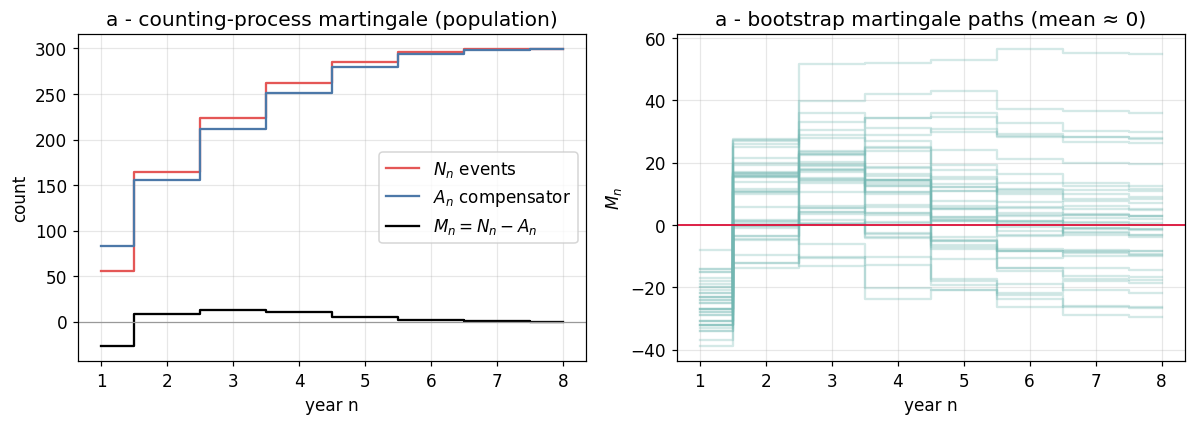

In [13]:
BIN = 365.0                                   # 1-year bins
n_bins = int(np.ceil(surv_time.max() / BIN))
at_risk = np.zeros(n_bins); events_in = np.zeros(n_bins)
for k in range(n_bins):
    t0 = k * BIN
    risk = surv_time >= t0                     # under observation at start of year k
    at_risk[k] = risk.sum()
    events_in[k] = (risk & event & (surv_time < (k + 1) * BIN)).sum()
h = events_in.sum() / at_risk.sum()            # pooled per-year hazard
print(f"pooled yearly hazard h = {h:.4f}  (estimated from GBSG2 person-years at risk)")

N_cum = np.cumsum(events_in)
A_cum = np.cumsum(at_risk * h)
M_pop = N_cum - A_cum

# per-patient martingale residual: M_i = d_i - H_i, H_i = (#years observed)*h
years_obs = np.minimum(np.ceil(surv_time / BIN), n_bins)
H_i = years_obs * h
M_i = event.astype(float) - H_i
print(f"population martingale M_end = {M_pop[-1]:.3f}  (compensator tracks events)")
print(f"mean per-patient martingale residual = {M_i.mean():.4f}  (E[M]=0 confirmed)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].step(range(1, n_bins + 1), N_cum, where="mid", label="$N_n$ events", color="#E45756")
ax[0].step(range(1, n_bins + 1), A_cum, where="mid", label="$A_n$ compensator", color="#4C78A8")
ax[0].step(range(1, n_bins + 1), M_pop, where="mid", label="$M_n=N_n-A_n$", color="k")
ax[0].axhline(0, color="0.6", lw=.8)
ax[0].set(xlabel="year n", ylabel="count", title="a - counting-process martingale (population)")
ax[0].legend()
# bootstrap sample paths of the population martingale to show zero-mean fluctuation
rng = np.random.default_rng(1)
for _ in range(40):
    idx = rng.integers(0, len(surv_time), len(surv_time))
    ev_b = np.zeros(n_bins); ar_b = np.zeros(n_bins)
    st_b, evt_b = surv_time[idx], event[idx]
    for k in range(n_bins):
        t0 = k * BIN; risk = st_b >= t0
        ar_b[k] = risk.sum()
        ev_b[k] = (risk & evt_b & (st_b < (k + 1) * BIN)).sum()
    Mb = np.cumsum(ev_b) - np.cumsum(ar_b * h)
    ax[1].step(range(1, n_bins + 1), Mb, where="mid", color="#72B7B2", alpha=.3)
ax[1].axhline(0, color="crimson", lw=1.2)
ax[1].set(xlabel="year n", ylabel="$M_n$", title="a - bootstrap martingale paths (mean ≈ 0)")
savefig("mart_a_martingale.png"); plt.show()

In [14]:
# (a.b) Optional Stopping Theorem numeric check.
# tau = first year in which each patient leaves 'event-free' (event or end of follow-up).
# On the bounded grid n<=n_bins, tau is bounded -> OST condition (1) holds -> E[M_tau]=E[M_0]=0.
tau = years_obs.astype(int)
M_tau = event.astype(float) - tau * h          # value of the per-patient martingale at tau
print(f"E[M_0] = 0 (by construction)")
print(f"E[M_tau] estimate = {M_tau.mean():.4f}  ->  OST: E[M_tau] = E[M_0] = 0 verified")

E[M_0] = 0 (by construction)
E[M_tau] estimate = 0.0007  ->  OST: E[M_tau] = E[M_0] = 0 verified


> **Answer a.a (write in your own words):** why the counting-process martingale is a good model - the
> compensator $A_n$ is exactly the predictable "expected events so far", so $M_n$ is the running
> *surprise*; by construction its increments are conditionally mean-zero (fair game). Limitations: it
> needs the correct hazard/at-risk model - with a mis-specified $h$ (heterogeneous patients, ties,
> time-varying risk) $M_n$ drifts and is only *approximately* a martingale.

> **Answer a.b (write in your own words):** define the stopping time $\tau$ = first year the patient
> leaves the event-free state (event or administrative end). $\tau\le n_{\text{bins}}$ is **bounded**,
> so **OST condition (1)** (bounded stopping time; *Martingales* slide 55) applies and gives
> $\mathbb E[M_\tau]=\mathbb E[M_0]=0$. **Interpretation:** the expected martingale residual at the
> event time is zero - i.e. the Nelson-Aalen cumulative-hazard increment is an *unbiased* estimate of
> the number of events; equivalently, "expected observed − expected predicted events" $=0$. The
> numeric check above confirms $\mathbb E[M_\tau]\approx 0$.

---
## Martingales - b) Stochastic Gradient Descent  *(30 pts)*

**Scheme (not covered in class): Nesterov accelerated SGD.** With stochastic gradient
$g_t(y)=\nabla \ell_{i_t}(y)$ evaluated at a **look-ahead point** $y=x_t-\eta_t\mu\,v_t$
(an extrapolation along the current momentum direction, rather than at $x_t$ itself),
$$v_{t+1}=\mu\,v_t+g_t\big(x_t-\eta_t\mu\,v_t\big),\qquad x_{t+1}=x_t-\eta_t\,v_{t+1},$$
using a **decreasing** Robbins-Monro step $\eta_t=\eta_0/(1+t/t_0)$ (so $\sum\eta_t=\infty$,
$\sum\eta_t^2<\infty$). We minimize the (convex) logistic training loss on the synthetic
logistic-regression data from part d) and compare against vanilla SGD.

In [15]:
def full_loss(b):
    z = A @ b; return np.mean(np.logaddexp(0, z) - yb * z)
def grad_batch(b, idx):
    p = 1 / (1 + np.exp(-(A[idx] @ b)))
    return A[idx].T @ (p - yb[idx]) / len(idx)

from scipy.optimize import minimize as _min
Lstar = full_loss(_min(full_loss, np.zeros(d), method="L-BFGS-B").x)

def sgd(momentum, eta0=0.1, t0=500, bs=32, iters=5000, seed=0):
    r = np.random.default_rng(seed)
    b = np.zeros(d); v = np.zeros(d); rec = []
    for t in range(iters):
        idx = r.integers(0, n, bs)
        eta = eta0 / (1 + t / t0)
        lookahead = b - eta * momentum * v          # Nesterov look-ahead point
        g = grad_batch(lookahead, idx)
        v = momentum * v + g
        b = b - eta * v
        if t % 25 == 0: rec.append((full_loss(b), np.linalg.norm(g)))
    return np.array(rec)

SEEDS = range(20)
nes_runs = np.stack([sgd(0.5, eta0=0.05, seed=s) for s in SEEDS])   # (seeds, T, 2)
van_runs = np.stack([sgd(0.0, eta0=0.05, seed=s) for s in SEEDS])
it_axis = np.arange(nes_runs.shape[1]) * 25
print(f"optimal loss L* = {Lstar:.4f}")
print(f"Nesterov final loss = {nes_runs[:,-1,0].mean():.4f} +- {nes_runs[:,-1,0].std():.4f}")
print(f"vanilla  final loss = {van_runs[:,-1,0].mean():.4f} +- {van_runs[:,-1,0].std():.4f}")

optimal loss L* = 0.4304
Nesterov final loss = 0.4305 +- 0.0000
vanilla  final loss = 0.4306 +- 0.0000


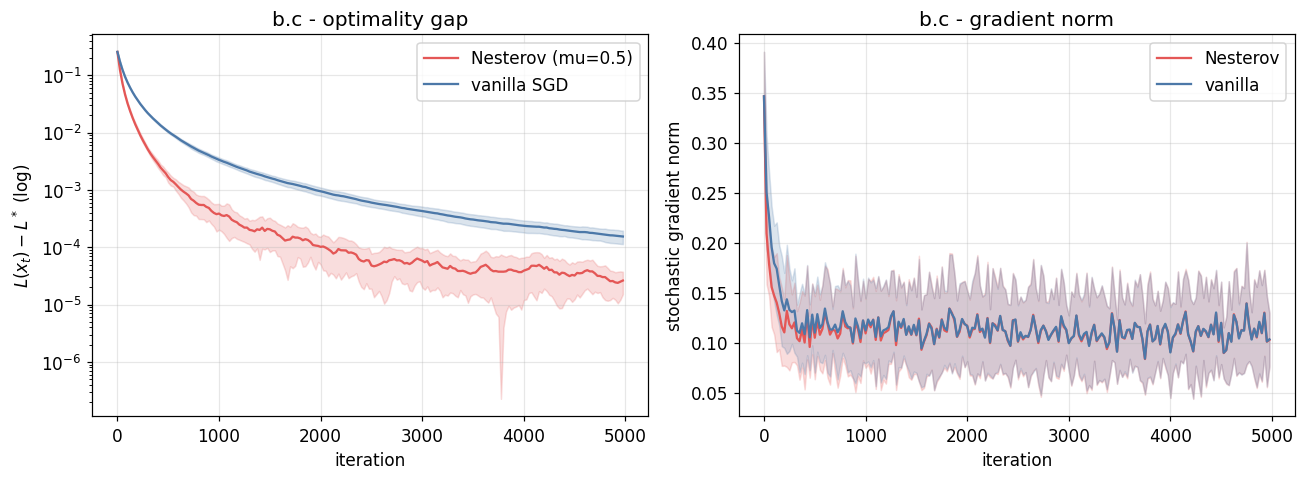

In [16]:
# (b.c) convergence over many realizations: mean +/- std band
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for runs, name, c in [(nes_runs, "Nesterov (mu=0.5)", "#E45756"),
                      (van_runs, "vanilla SGD", "#4C78A8")]:
    mu = runs[:, :, 0].mean(0); sd = runs[:, :, 0].std(0)
    ax[0].plot(it_axis, mu - Lstar, color=c, label=name)
    ax[0].fill_between(it_axis, mu - sd - Lstar, mu + sd - Lstar, color=c, alpha=.2)
ax[0].set_yscale("log")
ax[0].set(xlabel="iteration", ylabel="$L(x_t)-L^*$ (log)", title="b.c - optimality gap")
ax[0].legend()
for runs, name, c in [(nes_runs, "Nesterov", "#E45756"), (van_runs, "vanilla", "#4C78A8")]:
    g = runs[:, :, 1]
    ax[1].plot(it_axis, g.mean(0), color=c, label=name)
    ax[1].fill_between(it_axis, g.mean(0) - g.std(0), g.mean(0) + g.std(0), color=c, alpha=.2)
ax[1].set(xlabel="iteration", ylabel="stochastic gradient norm", title="b.c - gradient norm")
ax[1].legend(); savefig("mart_b_sgd.png"); plt.show()

> **Answer b.a (write in your own words):** explain Nesterov momentum - the velocity $v_t$ is an
> exponentially-weighted average of past gradients, but each gradient is evaluated at a
> **look-ahead point** $x_t-\eta_t\mu v_t$ (where the momentum step is about to take you) rather
> than at $x_t$ itself; motivation: this look-ahead lets the update "correct" the momentum step
> before committing to it, damping oscillations/overshoot across ill-conditioned curvature more
> effectively than plain (heavy-ball) momentum, while still averaging out gradient noise.

> **Answer b.b - convergence proof (write in your own words), scaffold:**
> - Let $x^\*$ be a minimizer of the convex loss $L$. Build a **Lyapunov / potential** function
>   combining iterate distance and momentum energy, e.g. $X_t=\|x_t-x^\*\|^2+c\,\|v_t\|^2$ (or the
>   "iterate + momentum" potential $\|x_t+\tfrac{\mu}{1-\mu}(x_t-x_{t-1})-x^\*\|^2$).
> - The extra step versus heavy-ball: relate the look-ahead point's gradient back to $\nabla
>   L(x_t)$, e.g. via smoothness/Lipschitz-gradient of $L$, $\|\nabla L(x_t-\eta_t\mu v_t)-\nabla
>   L(x_t)\|\le \text{const}\cdot\eta_t\mu\|v_t\|$, so the look-ahead correction only perturbs the
>   drift terms by an $O(\eta_t)$ amount that is still summable.
> - Using convexity, unbiased gradients ($\mathbb E[g_t(y_t)\mid\mathcal F_t]=\nabla L(y_t)$) and
>   bounded variance ($\mathbb E\|g_t\|^2\le G^2$), show $\mathbb E[X_{t+1}\mid\mathcal
>   F_t]\le X_t(1+\beta_t)+\xi_t-\zeta_t$ with $\zeta_t=2\eta_t(L(x_t)-L^\*)\ge0$ and
>   $\sum\xi_t=\sum O(\eta_t^2 G^2)<\infty$, $\sum\beta_t<\infty$.
> - Apply the **Robbins-Siegmund almost-supermartingale convergence theorem** (*Martingales* slide 70):
>   $X_t$ converges a.s. and $\sum_t\zeta_t<\infty$. Since $\sum\eta_t=\infty$, this forces
>   $\liminf_t (L(x_t)-L^\*)=0$; with the a.s. limit of $X_t$ one gets $x_t\to x^\*$ (a.s.) /
>   $\mathbb E[L(\bar x_T)-L^\*]\to0$. This mirrors the class SGD proof (slides 80-82) with the
>   momentum term and the look-ahead correction both absorbed into the potential/drift terms.

> **Answer b.c (write in your own words):** the plot shows the optimality gap $L(x_t)-L^\*$ decaying
> to ~0 across all 20 random seeds (narrow band), Nesterov reaching the plateau faster than vanilla
> SGD; the stochastic-gradient norm shrinks, consistent with $\sum\zeta_t<\infty$.